# Basic Tests for CartPoleWindPCH

Compares observational (`see()`) vs basic interventional (`do(action)`) policies.

In the Windy Cartpole game, the goal is still to keep the pole up straight. However, there is a wind blowing from either left or right. In pure do regime, this degenerates to a random/noisy cartpole but once the task involves see() or ctf_do or cool regime, the agent can potentially utilize the wind information from the behavioral policy's action choice.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from causal_gym.envs.cartpole_wind import CartPoleWindPCH
import warnings
warnings.filterwarnings("ignore", category=UserWarning,
                        message="Overriding environment .* already in registry")

In [2]:
# Parameters
N_EPISODES = 500 # Reduced episodes for faster basic tests
HORIZON = 200
TARGET_ACTION = 0 # Example: Intervene with action 0 (Push cart left)

In [3]:
# Helper functions (similar to test_lander.py/test_frozenlake.py)
def run_observational(env, n_episodes, horizon):
    """Runs the environment under the observational policy."""
    total_rewards = []
    print("Running Observational...")
    for ep in range(n_episodes):
        if (ep + 1) % (n_episodes // 10) == 0:
            print(f"  Obs episode {ep + 1}/{n_episodes}", flush=True)
        env.reset()
        episode_reward = 0
        for _ in range(horizon):
            _, _, r, terminated, truncated, _ = env.see() # Get reward from see()
            episode_reward += r
            if terminated or truncated:
                break
        total_rewards.append(episode_reward)
    print("Observational finished.")
    return np.mean(total_rewards) # Return average total reward

def run_interventional(env, n_episodes, horizon, action):
    """Runs the environment under a fixed interventional policy."""
    total_rewards = []
    print(f"Running Interventional (do={action})...")
    for ep in range(n_episodes):
        if (ep + 1) % (n_episodes // 10) == 0:
            print(f"  Int episode {ep + 1}/{n_episodes}", flush=True)
        env.reset()
        episode_reward = 0
        for _ in range(horizon):
            _, r, terminated, truncated, _ = env.do(action) # Get reward from do()
            episode_reward += r
            if terminated or truncated:
                break
        total_rewards.append(episode_reward)
    print("Interventional finished.")
    return np.mean(total_rewards) # Return average total reward

In [4]:
from causal_gym.core import Task
# Main Experiment
# Note that for each experiment we need to be specific about the learning 
# regime, otherwise the related function cannot be called.
# 1. Observational
env_obs = CartPoleWindPCH(task=Task(learning_regime='see'))
avg_reward_obs = run_observational(env_obs, N_EPISODES, HORIZON)
print(f"Avg Reward (see) ≈ {avg_reward_obs:.2f}")

# 2. Interventional
env_int = CartPoleWindPCH(task=Task(learning_regime='do'))
avg_reward_int = run_interventional(env_int, N_EPISODES, HORIZON, TARGET_ACTION)
print(f"Avg Reward (do={TARGET_ACTION}) ≈ {avg_reward_int:.2f}")

Running Observational...
  Obs episode 50/500
  Obs episode 100/500
  Obs episode 150/500
  Obs episode 200/500
  Obs episode 250/500
  Obs episode 300/500
  Obs episode 350/500
  Obs episode 400/500
  Obs episode 450/500
  Obs episode 500/500
Observational finished.
Avg Reward (see) ≈ 22.05
Running Interventional (do=0)...
  Int episode 50/500
  Int episode 100/500
  Int episode 150/500
  Int episode 200/500
  Int episode 250/500
  Int episode 300/500
  Int episode 350/500
  Int episode 400/500
  Int episode 450/500
  Int episode 500/500
Interventional finished.
Avg Reward (do=0) ≈ 9.20


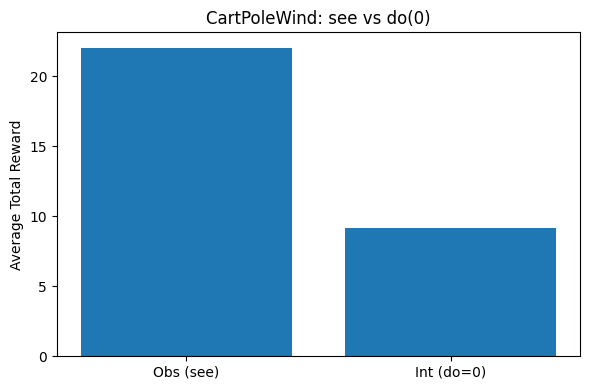

In [5]:
# Plotting Results
labels = ['Obs (see)', f'Int (do={TARGET_ACTION})']
avg_rewards = [avg_reward_obs, avg_reward_int]

plt.figure(figsize=(6, 4))
plt.bar(labels, avg_rewards)
# plt.ylim(0, HORIZON + 10) # Optional: Set y-limit if needed
plt.ylabel('Average Total Reward')
plt.title(f'CartPoleWind: see vs do({TARGET_ACTION})')
plt.tight_layout()
plt.savefig('cartpole_probs_basic.png') # Save the plot
plt.show()

In [6]:
env = CartPoleWindPCH(task=Task(learning_regime='see'))
graph = env.get_graph

In [7]:
graph.nodes

[{'name': 'S', 'label': 'State', 'type_': 'basic', 'metadata': {}},
 {'name': 'X', 'label': 'Action', 'type_': 'basic', 'metadata': {}},
 {'name': 'Y', 'label': 'Reward', 'type_': 'basic', 'metadata': {}},
 {'name': "S'", 'label': 'Next State', 'type_': 'basic', 'metadata': {}}]

In [8]:
graph.edges

[{'from_': 'S',
  'to_': 'X',
  'label': None,
  'type_': 'directed',
  'metadata': {}},
 {'from_': 'S',
  'to_': 'Y',
  'label': None,
  'type_': 'directed',
  'metadata': {}},
 {'from_': 'S',
  'to_': "S'",
  'label': None,
  'type_': 'directed',
  'metadata': {}},
 {'from_': 'X',
  'to_': 'Y',
  'label': None,
  'type_': 'directed',
  'metadata': {}},
 {'from_': 'X',
  'to_': "S'",
  'label': None,
  'type_': 'directed',
  'metadata': {}},
 {'from_': "S'",
  'to_': 'X',
  'label': None,
  'type_': 'bidirected',
  'metadata': {}}]